# Simplified 2D TMz FDTD-like Radiation from a Prescribed Rotating Amorphous Dipole Source (take 3)

This notebook builds a **source-first electromagnetic radiation model** in normalized units:
1. Prescribed source $\rho, \mathbf{J}$
2. Simplified 2D TM$_z$ FDTD-like Maxwell update
3. Fields $E_x, E_y, B_z$
4. Radiation and consistency diagnostics

The scientific goal is **qualitative radiation behavior** and numerical diagnostics. It is not presented as a precision electromagnetic solver.

## What this model does and does not solve

This notebook models electromagnetic radiation from an externally prescribed rotating charge/current distribution. The source is not evolved self-consistently by the Lorentz force, and the electric field is not initialized from the electrostatic Poisson solution. Therefore, Gauss's law is monitored as a diagnostic rather than exactly enforced. The goal is to study qualitative radiation behavior, Poynting flux, boundary effects, and frequency trends in a simplified 2D TMz FDTD-like model.

**Important numerical framing**
- $E_x$, $E_y$, and $B_z$ are stored on the same collocated grid.
- This is **not** a full Yee-lattice FDTD implementation.
- This approach is appropriate for upper-division computational physics exploration, not precision electromagnetic prediction.

## 1) Imports and constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Normalized units
epsilon0 = 1.0
mu0 = 1.0
c = 1.0

np.set_printoptions(precision=4, suppress=True)

## 2) Grid setup

In [2]:
def make_grid(Nx, Ny, Lx=10.0, Ly=10.0):
    x = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False)
    y = np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
    dx = Lx / Nx
    dy = Ly / Ny
    X, Y = np.meshgrid(x, y, indexing='xy')
    return x, y, X, Y, dx, dy

Nx = Ny = 2500
Lx = Ly = 7.0
x, y, X, Y, dx, dy = make_grid(Nx=Nx, Ny=Ny, Lx=Lx, Ly=Ly)

dt = 0.7 * min(dx, dy) / c
cfl = c * dt / dx
cfl_limit_2d = 1.0 / np.sqrt(2.0)
is_stable = cfl <= cfl_limit_2d

print(f"dx = {dx:.6f}")
print(f"dt = {dt:.6f}")
print(f"c = {c:.6f}")
print(f"CFL = c*dt/dx = {cfl:.6f}")
print(f"CFL limit (2D wave, approx) = {cfl_limit_2d:.6f}")
print(f"Stable? {'YES' if is_stable else 'NO'}")

if not is_stable:
    raise ValueError('CFL condition violated: reduce dt or increase grid spacing.')

dx = 0.002800
dt = 0.001960
c = 1.000000
CFL = c*dt/dx = 0.700000
CFL limit (2D wave, approx) = 0.707107
Stable? YES


## 3) Amorphous charge blob generation

In [3]:
def amorphous_blob(X, Y, x0, y0, a, b, amplitude=1.0, phase=0.0):
    theta = np.arctan2(Y - y0, X - x0)
    distortion = 1.0 + 0.15 * np.cos(3.0 * theta + phase) + 0.10 * np.sin(5.0 * theta)
    envelope = np.exp(-(((X - x0)**2) / a**2 + ((Y - y0)**2) / b**2))
    return amplitude * envelope * distortion

def rotating_rho(X, Y, t, omega, Q=1.0, sep=1.0, a=0.35, b=0.24, phase=0.6, dx=1.0, dy=1.0):
    angle = omega * t
    ca, sa = np.cos(angle), np.sin(angle)

    # Counterclockwise rotating source coordinates
    x_rot = X * ca + Y * sa
    y_rot = -X * sa + Y * ca

    rho_pos_raw = amorphous_blob(x_rot, y_rot, +sep/2, 0.0, a, b, amplitude=1.0, phase=phase)
    rho_neg_raw = amorphous_blob(x_rot, y_rot, -sep/2, 0.0, a, b, amplitude=1.0, phase=-phase)

    q_pos_raw = np.sum(rho_pos_raw) * dx * dy
    q_neg_raw = np.sum(rho_neg_raw) * dx * dy

    rho_pos = rho_pos_raw * (Q / q_pos_raw)
    rho_neg = rho_neg_raw * (-Q / q_neg_raw)
    rho = rho_pos + rho_neg
    return rho, rho_pos, rho_neg

rho0, rho_p0, rho_n0 = rotating_rho(X, Y, t=0.0, omega=0.8, Q=1.0, sep=1.0, a=0.35, b=0.24, phase=0.6, dx=dx, dy=dy)
print('Net charge at t=0:', np.sum(rho0) * dx * dy)

Net charge at t=0: -5.766208820999763e-16


## 4) Time-dependent rotating dipole source

The source rotates rigidly around the origin with angular velocity $\omega$.

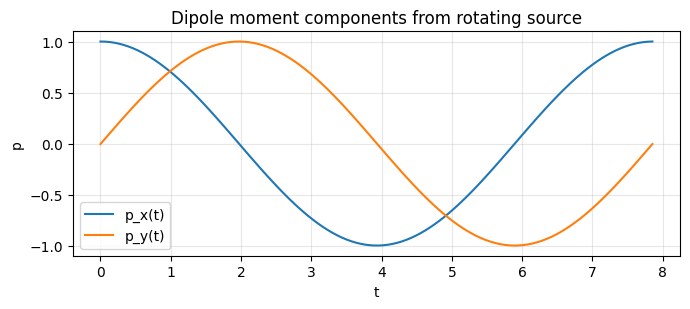

In [4]:
def compute_dipole_moment(rho, X, Y, dx, dy):
    px = np.sum(X * rho) * dx * dy
    py = np.sum(Y * rho) * dx * dy
    return px, py

times_demo = np.linspace(0, 2*np.pi/0.8, 120)
px_demo, py_demo = [], []
for t in times_demo:
    rho_t, *_ = rotating_rho(X, Y, t=t, omega=0.8, Q=1.0, sep=1.0, a=0.35, b=0.24, phase=0.6, dx=dx, dy=dy)
    px_t, py_t = compute_dipole_moment(rho_t, X, Y, dx, dy)
    px_demo.append(px_t)
    py_demo.append(py_t)

plt.figure(figsize=(7, 3.2))
plt.plot(times_demo, px_demo, label='p_x(t)')
plt.plot(times_demo, py_demo, label='p_y(t)')
plt.title('Dipole moment components from rotating source')
plt.xlabel('t')
plt.ylabel('p')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5) Current density from rigid rotation

In [5]:
def compute_current(rho, X, Y, omega):
    vx = -omega * Y
    vy =  omega * X
    Jx = rho * vx
    Jy = rho * vy
    return Jx, Jy

def ddx_centered_nonperiodic(F, dx):
    dF = np.empty_like(F)
    dF[:, 1:-1] = (F[:, 2:] - F[:, :-2]) / (2*dx)
    dF[:, 0] = (F[:, 1] - F[:, 0]) / dx
    dF[:, -1] = (F[:, -1] - F[:, -2]) / dx
    return dF

def ddy_centered_nonperiodic(F, dy):
    dF = np.empty_like(F)
    dF[1:-1, :] = (F[2:, :] - F[:-2, :]) / (2*dy)
    dF[0, :] = (F[1, :] - F[0, :]) / dy
    dF[-1, :] = (F[-1, :] - F[-2, :]) / dy
    return dF

def divergence(Jx, Jy, dx, dy):
    dJx_dx = ddx_centered_nonperiodic(Jx, dx)
    dJy_dy = ddy_centered_nonperiodic(Jy, dy)
    return dJx_dx + dJy_dy

rho_prev, *_ = rotating_rho(X, Y, t=-dt, omega=0.8, Q=1.0, sep=0.6, a=0.35, b=0.24, phase=0.6, dx=dx, dy=dy)
rho_now, *_ = rotating_rho(X, Y, t=0.0, omega=0.8, Q=1.0, sep=0.6, a=0.35, b=0.24, phase=0.6, dx=dx, dy=dy)
rho_next, *_ = rotating_rho(X, Y, t=dt, omega=0.8, Q=1.0, sep=0.6, a=0.35, b=0.24, phase=0.6, dx=dx, dy=dy)
Jx_now, Jy_now = compute_current(rho_now, X, Y, omega=0.8)

drho_dt = (rho_next - rho_prev) / (2.0 * dt)
divJ = divergence(Jx_now, Jy_now, dx, dy)
continuity = drho_dt + divJ

core = (slice(2, -2), slice(2, -2))
cont_rms = np.sqrt(np.mean(continuity[core]**2))
cont_denom = np.sqrt(np.mean(drho_dt[core]**2)) + np.sqrt(np.mean(divJ[core]**2)) + 1e-12
cont_norm = cont_rms / cont_denom

print('Continuity residual RMS (demo):', cont_rms)
print('Normalized continuity residual (demo):', cont_norm)

Continuity residual RMS (demo): 0.2169870532512529
Normalized continuity residual (demo): 0.2430573385499591


## 6) Simplified 2D TMz FDTD-like Maxwell update on a collocated grid

We evolve $E_x$, $E_y$, and $B_z$ on the same collocated grid with finite-difference derivatives. This is not a full Yee-lattice FDTD staggering, so results should be interpreted as qualitative numerical physics diagnostics rather than precision electromagnetic benchmarks.

In [6]:
def curl_E_to_B(Ex, Ey, dx, dy):
    dEy_dx = ddx_centered_nonperiodic(Ey, dx)
    dEx_dy = ddy_centered_nonperiodic(Ex, dy)
    return dEy_dx - dEx_dy

def curl_B_to_E(Bz, dx, dy):
    dBz_dx = ddx_centered_nonperiodic(Bz, dx)
    dBz_dy = ddy_centered_nonperiodic(Bz, dy)
    return dBz_dx, dBz_dy

def compute_divE(Ex, Ey, dx, dy):
    return ddx_centered_nonperiodic(Ex, dx) + ddy_centered_nonperiodic(Ey, dy)

def compute_poynting(Ex, Ey, Bz, mu0=1.0):
    Sx = Ey * Bz / mu0
    Sy = -Ex * Bz / mu0
    return Sx, Sy

## 7) Legacy sponge damping preview only, not used in final simulation

In [7]:
def make_damping_mask(Nx, Ny, width=24, strength=4.0):
    ii, jj = np.indices((Ny, Nx))
    dist_edge = np.minimum.reduce([ii, jj, Ny - 1 - ii, Nx - 1 - jj]).astype(float)

    s = np.clip(dist_edge / width, 0.0, 1.0)
    mask = np.where(s < 1.0, np.exp(-strength * (1.0 - s)**2), 1.0)
    return mask

# Legacy sponge damping preview only, not used in final simulation.
show_legacy_sponge_preview = False
if show_legacy_sponge_preview:
    sponge_mask = make_damping_mask(Nx, Ny, width=24, strength=4.0)
    plt.figure(figsize=(4.8, 4.2))
    plt.imshow(sponge_mask, origin='lower', cmap='viridis', extent=[x.min(), x.max(), y.min(), y.max()])
    plt.colorbar(label='Damping factor (dimensionless)')
    plt.title('Legacy sponge damping preview only, not used in final simulation')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.tight_layout()
    plt.show()

The legacy sponge damping layer is kept only as an optional visualization preview. The final simulation results use first-order Mur absorbing boundary conditions (ABC), not sponge damping.

Mur ABC is still approximate (especially for oblique incidence), but it is more physically motivated for outgoing-wave behavior than uniform edge damping.

## 8) Visualization helpers + core simulation runner

In [8]:
def measure_flux_ring(Sx, Sy, X, Y, r_obs=3.2, ntheta=240):
    theta = np.linspace(0, 2*np.pi, ntheta, endpoint=False)
    dtheta = 2*np.pi / ntheta
    xr = r_obs * np.cos(theta)
    yr = r_obs * np.sin(theta)

    x_vals = X[0, :]
    y_vals = Y[:, 0]

    ix = np.clip(np.searchsorted(x_vals, xr), 1, len(x_vals)-1)
    iy = np.clip(np.searchsorted(y_vals, yr), 1, len(y_vals)-1)

    choose_left_x = np.abs(x_vals[ix-1] - xr) < np.abs(x_vals[ix] - xr)
    choose_left_y = np.abs(y_vals[iy-1] - yr) < np.abs(y_vals[iy] - yr)
    ix = np.where(choose_left_x, ix-1, ix)
    iy = np.where(choose_left_y, iy-1, iy)

    Sr = Sx[iy, ix] * np.cos(theta) + Sy[iy, ix] * np.sin(theta)
    intensity = np.maximum(Sr, 0.0)

    signed_power = r_obs * np.sum(Sr) * dtheta
    outward_power = r_obs * np.sum(intensity) * dtheta
    return theta, Sr, intensity, dtheta, signed_power, outward_power

def apply_mur_abc(u, u_old, c, dt, dx, dy):
    """
    First-order Mur absorbing boundary condition for a 2D scalar field.
    Apply separately to Ex, Ey, and Bz.
    """
    u_new = u.copy()

    coef_x = (c*dt - dx) / (c*dt + dx)
    coef_y = (c*dt - dy) / (c*dt + dy)

    # left and right boundaries
    u_new[:, 0]  = u_old[:, 1]  + coef_x * (u[:, 1]  - u_old[:, 0])
    u_new[:, -1] = u_old[:, -2] + coef_x * (u[:, -2] - u_old[:, -1])

    # bottom and top boundaries
    u_new[0, :]  = u_old[1, :]  + coef_y * (u[1, :]  - u_old[0, :])
    u_new[-1, :] = u_old[-2, :] + coef_y * (u[-2, :] - u_old[-1, :])

    return u_new

def run_fdtd(
    X, Y, dx, dy, dt, nsteps=1400, omega=0.8,
    Q=1.0, sep=1.0, a=0.35, b=0.24, phase=0.6,
    save_interval=10,
    continuity_check_interval=120,
    r_obs=3.2, ntheta_ring=180, store_frames=True,
    progress_ticks=False, progress_label='FDTD compile'
):
    Ny, Nx = X.shape
    Ex = np.zeros((Ny, Nx), dtype=float)
    Ey = np.zeros((Ny, Nx), dtype=float)
    Bz = np.zeros((Ny, Nx), dtype=float)

    cfl_ratio = c * dt / dx
    cfl_limit = 1.0 / np.sqrt(2.0)
    if cfl_ratio > cfl_limit:
        raise ValueError(f'CFL condition violated in run_fdtd: CFL={cfl_ratio:.4f} > {cfl_limit:.4f}')

    t_arr = np.arange(nsteps) * dt
    px_arr = np.zeros(nsteps)
    py_arr = np.zeros(nsteps)
    flux_signed = np.zeros(nsteps)
    flux_outward = np.zeros(nsteps)

    diag_t = []
    continuity_rms = []
    continuity_norm = []
    gauss_rms = []

    frames_Bz = []
    frames_rho = []
    frames_Ex = []
    frames_Ey = []
    frame_steps = []

    transient_time_est = r_obs / c
    small_number = 1e-12

    tick_interval = max(1, nsteps // 40)
    start_time = time.perf_counter()
    if progress_ticks:
        print(f"{progress_label}: ", end='', flush=True)

    for n, t in enumerate(t_arr):
        rho, _, _ = rotating_rho(X, Y, t=t, omega=omega, Q=Q, sep=sep, a=a, b=b, phase=phase, dx=dx, dy=dy)
        Jx, Jy = compute_current(rho, X, Y, omega=omega)

        Ex_prev = Ex.copy()
        Ey_prev = Ey.copy()
        Bz_prev = Bz.copy()

        # Simplified collocated-grid TMz Maxwell updates (not Yee-staggered).
        Bz -= dt * curl_E_to_B(Ex, Ey, dx, dy)
        dBz_dx, dBz_dy = curl_B_to_E(Bz, dx, dy)
        Ex += dt * (c**2 * dBz_dy - Jx / epsilon0)
        Ey += dt * (-c**2 * dBz_dx - Jy / epsilon0)

        # First-order Mur ABC boundaries
        Ex = apply_mur_abc(Ex, Ex_prev, c, dt, dx, dy)
        Ey = apply_mur_abc(Ey, Ey_prev, c, dt, dx, dy)
        Bz = apply_mur_abc(Bz, Bz_prev, c, dt, dx, dy)

        # Dipole diagnostics
        px_arr[n], py_arr[n] = compute_dipole_moment(rho, X, Y, dx, dy)

        # Poynting ring flux diagnostics
        Sx, Sy = compute_poynting(Ex, Ey, Bz, mu0=mu0)
        _, _, _, _, flux_s, flux_o = measure_flux_ring(Sx, Sy, X, Y, r_obs=r_obs, ntheta=ntheta_ring)
        flux_signed[n] = flux_s
        flux_outward[n] = flux_o

        # Continuity and Gauss diagnostics (sampled)
        if (n % continuity_check_interval == 0):
            core = (slice(2, -2), slice(2, -2))

            if 0 < n < (nsteps - 1):
                rho_prev = rotating_rho(
                    X, Y, t=t_arr[n-1], omega=omega, Q=Q, sep=sep, a=a, b=b, phase=phase, dx=dx, dy=dy
                )[0]
                rho_next = rotating_rho(
                    X, Y, t=t_arr[n+1], omega=omega, Q=Q, sep=sep, a=a, b=b, phase=phase, dx=dx, dy=dy
                )[0]
                drho_dt = (rho_next - rho_prev) / (2.0 * dt)
                divJ = divergence(Jx, Jy, dx, dy)
                continuity = drho_dt + divJ

                cont_rms = np.sqrt(np.mean(continuity[core]**2))
                denom = (
                    np.sqrt(np.mean(drho_dt[core]**2))
                    + np.sqrt(np.mean(divJ[core]**2))
                    + small_number
                )
                continuity_rms.append(cont_rms)
                continuity_norm.append(cont_rms / denom)
            else:
                continuity_rms.append(np.nan)
                continuity_norm.append(np.nan)

            divE = compute_divE(Ex, Ey, dx, dy)
            gauss_residual = divE - rho / epsilon0
            gauss_rms.append(np.sqrt(np.mean(gauss_residual[core]**2)))
            diag_t.append(t)

        if progress_ticks and ((n + 1) % tick_interval == 0 or (n + 1) == nsteps):
            print('✓', end='', flush=True)

        if store_frames and (n % save_interval == 0):
            frames_Bz.append(Bz.copy())
            frames_rho.append(rho.copy())
            frames_Ex.append(Ex.copy())
            frames_Ey.append(Ey.copy())
            frame_steps.append(n)

    elapsed_time = time.perf_counter() - start_time
    if progress_ticks:
        print(f" done ({elapsed_time:.2f} s)")

    result = {
        't': t_arr,
        'Ex': Ex,
        'Ey': Ey,
        'Bz': Bz,
        'rho_last': rho,
        'frames_Bz': np.array(frames_Bz),
        'frames_rho': np.array(frames_rho),
        'frames_Ex': np.array(frames_Ex),
        'frames_Ey': np.array(frames_Ey),
        'frame_steps': np.array(frame_steps, dtype=int),
        'frame_t': t_arr[np.array(frame_steps, dtype=int)] if len(frame_steps) else np.array([]),
        'px': px_arr,
        'py': py_arr,
        'diag_t': np.array(diag_t),
        'continuity_rms': np.array(continuity_rms, dtype=float),
        'continuity_norm': np.array(continuity_norm, dtype=float),
        'gauss_rms': np.array(gauss_rms, dtype=float),
        'flux_signed': flux_signed,
        'flux_outward': flux_outward,
        'transient_time_est': transient_time_est,
        'ring_dtheta': 2*np.pi/ntheta_ring,
        'cfl_ratio': cfl_ratio,
        'cfl_limit': cfl_limit,
        'elapsed_time': elapsed_time
    }
    return result

def plot_snapshot(X, Y, rho, Ex, Ey, Bz, title='Snapshot', stride=9):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    im0 = axes[0].imshow(rho, origin='lower', extent=[X.min(), X.max(), Y.min(), Y.max()], cmap='coolwarm')
    axes[0].set_title('Charge density $\\rho(x,y)$')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, label='$\\rho$')

    im1 = axes[1].imshow(Bz, origin='lower', extent=[X.min(), X.max(), Y.min(), Y.max()], cmap='RdBu')
    axes[1].set_title('Magnetic field $B_z(x,y)$')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, label='$B_z$')

    axes[2].set_title('$\\mathbf{E}$ quiver over $B_z$')
    im2 = axes[2].imshow(Bz, origin='lower', extent=[X.min(), X.max(), Y.min(), Y.max()], cmap='RdBu', alpha=0.75)
    plt.colorbar(im2, ax=axes[2], fraction=0.046, label='$B_z$')
    axes[2].quiver(
        X[::stride, ::stride], Y[::stride, ::stride],
        Ex[::stride, ::stride], Ey[::stride, ::stride],
        color='k', alpha=0.8, scale=35
    )

    for ax in axes:
        ax.set_xlabel('x (dimensionless)')
        ax.set_ylabel('y (dimensionless)')
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

def animate_fields(result, X, Y, interval=40):
    frames_Bz = result['frames_Bz']
    frames_rho = result['frames_rho']
    if len(frames_Bz) == 0:
        raise ValueError('No frames stored. Run with store_frames=True and save_interval > 0.')

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
    imB = axes[0].imshow(frames_Bz[0], origin='lower', extent=[X.min(), X.max(), Y.min(), Y.max()], cmap='RdBu')
    imR = axes[1].imshow(frames_rho[0], origin='lower', extent=[X.min(), X.max(), Y.min(), Y.max()], cmap='coolwarm', alpha=0.85)
    imOverlay = axes[1].imshow(frames_Bz[0], origin='lower', extent=[X.min(), X.max(), Y.min(), Y.max()], cmap='RdBu', alpha=0.40)

    axes[0].set_title('Radiating $B_z$')
    axes[1].set_title('Overlay: $\\rho$ + $B_z$')
    for ax in axes:
        ax.set_xlabel('x (dimensionless)')
        ax.set_ylabel('y (dimensionless)')

    fig.tight_layout()

    def update(i):
        imB.set_data(frames_Bz[i])
        imR.set_data(frames_rho[i])
        imOverlay.set_data(frames_Bz[i])
        return imB, imR, imOverlay

    ani = FuncAnimation(fig, update, frames=len(frames_Bz), interval=interval, blit=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())

## 9) Run simulation + diagnostics: dipole moment, Poynting flux, radiation pattern

In [12]:
import time

# --- quick test run to estimate time per step ---
test_steps = 200

start = time.time()
_ = run_fdtd(
    X, Y, dx, dy, dt,
    nsteps=test_steps,
    omega=omega_main,
    sep=0.70, a=0.15, b=0.10, phase=0.6,
    save_interval=max(1, test_steps // 50),
    continuity_check_interval=max(1, test_steps // 50),
    r_obs=r_obs_main,
    ntheta_ring=360,
    store_frames=False,   # IMPORTANT: disable for timing test
    progress_ticks=False
)
end = time.time()

time_per_step = (end - start) / test_steps
estimated_runtime = time_per_step * nsteps_main

print(f"Time per step: {time_per_step:.6f} s")
print(f"Estimated total runtime: {estimated_runtime:.2f} s")

omega_main = 2.0
r_obs_main = 3.2
periods_main = 1.0
T_main = 2*np.pi / omega_main
total_time_main = periods_main * T_main + r_obs_main / c
nsteps_main = int(np.ceil(total_time_main / dt))

print(f"Running main FDTD simulation for {periods_main:.1f} periods (T={T_main:.3f}), total time {total_time_main:.3f}, nsteps={nsteps_main//120}")

result = run_fdtd(
    X, Y, dx, dy, dt, nsteps=nsteps_main, omega=omega_main,
    sep=0.70, a=0.15, b=0.10, phase=0.6,
    save_interval=max(1, nsteps_main // 160),
    continuity_check_interval=max(1, nsteps_main // 120),
    r_obs=r_obs_main, ntheta_ring=360, store_frames=False,
    progress_ticks=True, progress_label='Main FDTD compile'
)

print('Done. Final field RMS(Bz):', np.sqrt(np.mean(result['Bz']**2)))
print(f"dx={dx:.6f}, dt={dt:.6f}, c={c:.6f}")
print(f"CFL={result['cfl_ratio']:.6f}, CFL limit={result['cfl_limit']:.6f}, stable={result['cfl_ratio'] <= result['cfl_limit']}")
print(f"Estimated ring travel transient time r_obs/c = {result['transient_time_est']:.3f}")
if len(result['diag_t']) > 0:
    print('First diagnostic samples [t, continuity_norm, gauss_rms]:')
    for k in range(min(5, len(result['diag_t']))):
        print(result['diag_t'][k], result['continuity_norm'][k], result['gauss_rms'][k])
print(f"Compile/runtime elapsed: {result['elapsed_time']:.2f} s")


Time per step: 0.555392 s
Estimated total runtime: 1797.25 s
Running main FDTD simulation for 1.0 periods (T=3.142), total time 6.342, nsteps=26
Main FDTD compile: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (1341.00 s)
Done. Final field RMS(Bz): 0.18409848277316745
dx=0.002800, dt=0.001960, c=1.000000
CFL=0.700000, CFL limit=0.707107, stable=True
Estimated ring travel transient time r_obs/c = 3.200
First diagnostic samples [t, continuity_norm, gauss_rms]:
0.0 nan 0.6645840431864172
0.05096 0.1221226221245917 0.666093223392624
0.10192 0.12709700044104935 0.6668730494163675
0.15288 0.1202789386851993 0.6669958527287732
0.20384 0.11144914253488052 0.6666035219785248
Compile/runtime elapsed: 1341.00 s


In [13]:
# Five snapshots: start, 1/4, 1/2, 3/4, last
fractions = [0.0001, 0.25, 0.5, 0.75, 1.0]
labels = ['start', '1/4', '1/2', '3/4', 'last']

n_frames = len(result['frames_Bz'])
if n_frames == 0:
    raise ValueError('No saved frames found. Re-run cell 20 with store_frames=True.')

indices = [int(round(f * (n_frames - 1))) for f in fractions]

for idx, label in zip(indices, labels):
    t_snap = result['frame_t'][idx] if 'frame_t' in result and len(result['frame_t']) > idx else np.nan
    plot_snapshot(
        X, Y,
        result['frames_rho'][idx],
        result['frames_Ex'][idx],
        result['frames_Ey'][idx],
        result['frames_Bz'][idx],
        title=f'FDTD snapshot ({label}), t={t_snap:.3f}'
    )

ValueError: No saved frames found. Re-run cell 20 with store_frames=True.

**Figure commentary (charge and field snapshots).**
- **Plotted:** time snapshots of $\rho$, $B_z$, and quiver arrows of $(E_x,E_y)$.
- **Expected:** rotating source drives oscillatory near fields and outward-propagating wavefront structure in $B_z$.
- **Observed:** localized rotating charge distribution with evolving $B_z$ patterns and directional electric-field structure.
- **Interpretation:** supports qualitative radiation-like behavior; not a precision benchmark because of collocated-grid simplifications and finite-domain effects.

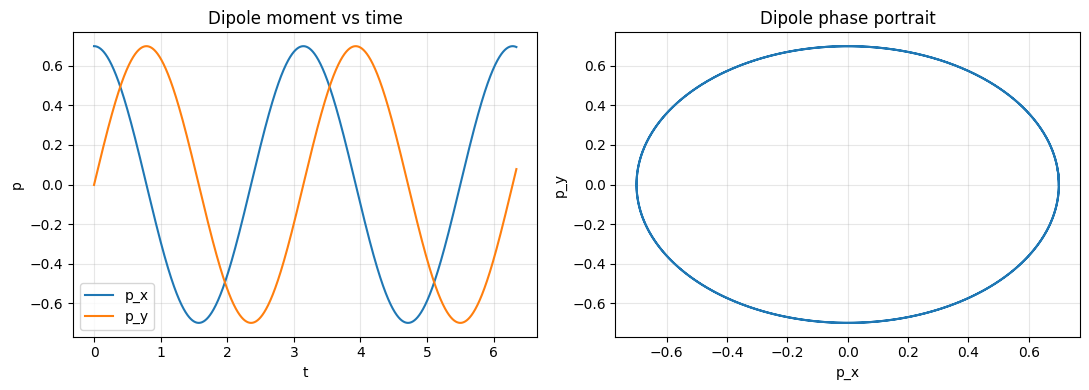

In [14]:
# Dipole moment trajectories
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(result['t'], result['px'], label='p_x')
ax[0].plot(result['t'], result['py'], label='p_y')
ax[0].set_title('Dipole moment vs time')
ax[0].set_xlabel('t')
ax[0].set_ylabel('p')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(result['px'], result['py'])
ax[1].set_title('Dipole phase portrait')
ax[1].set_xlabel('p_x')
ax[1].set_ylabel('p_y')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure commentary (dipole moment evolution).**
- **Plotted:** $p_x(t)$, $p_y(t)$, and phase portrait $(p_x,p_y)$.
- **Expected:** approximately rotating dipole moment trajectory with periodic behavior.
- **Observed:** periodic components and a closed-or-nearly-closed phase curve.
- **Interpretation:** qualitatively consistent with a prescribed rotating dipole-like source.

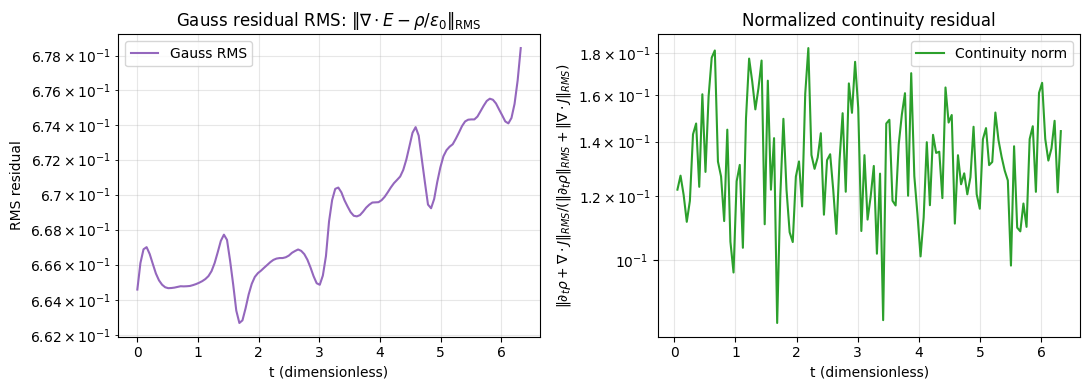

In [15]:
# Constraint diagnostics: Gauss-law RMS and normalized continuity residual
if len(result['diag_t']) > 0:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(result['diag_t'], result['gauss_rms'], color='tab:purple', label='Gauss RMS')
    ax[0].set_title(r"Gauss residual RMS: $\|\nabla\cdot E - \rho/\epsilon_0\|_{\mathrm{RMS}}$")
    ax[0].set_xlabel('t (dimensionless)')
    ax[0].set_ylabel('RMS residual')
    ax[0].set_yscale('log')
    ax[0].grid(alpha=0.3, which='both')
    ax[0].legend()

    ax[1].plot(result['diag_t'], result['continuity_norm'], color='tab:green', label='Continuity norm')
    ax[1].set_title('Normalized continuity residual')
    ax[1].set_xlabel('t (dimensionless)')
    ax[1].set_ylabel(
        r'$\|\partial_t\rho + \nabla\cdot J\|_{RMS}/(\|\partial_t\rho\|_{RMS}+\|\nabla\cdot J\|_{RMS})$'
    )
    ax[1].set_yscale('log')
    ax[1].grid(alpha=0.3, which='both')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No diagnostic samples found. Increase nsteps or reduce continuity_check_interval.')

**Figure commentary (continuity and Gauss diagnostics).**
- **Plotted:** RMS Gauss residual and normalized continuity residual versus time.
- **Expected:** nonzero residuals can occur because the source is prescribed externally and the electric field is not initialized from a Poisson solve.
- **Observed:** finite, time-varying residuals rather than exact constraint satisfaction.
- **Interpretation:** this is a known limitation of the model formulation, not evidence of full inconsistency by itself.

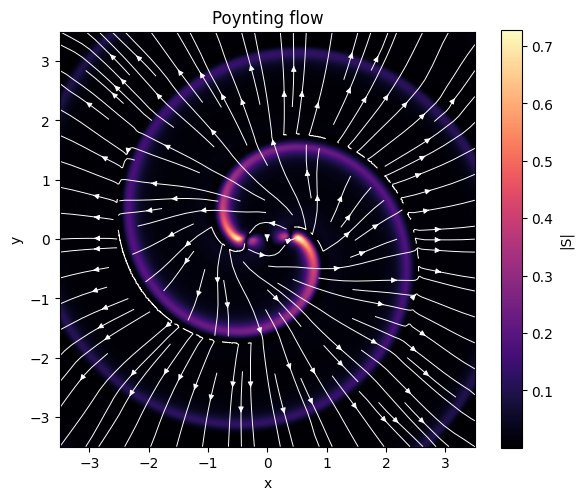

In [16]:
# Poynting vector visualization
Sx, Sy = compute_poynting(result['Ex'], result['Ey'], result['Bz'], mu0=mu0)

plt.figure(figsize=(6, 5))
plt.imshow(np.hypot(Sx, Sy), origin='lower', extent=[x.min(), x.max(), y.min(), y.max()], cmap='magma')
plt.colorbar(label='|S|')
plt.streamplot(x, y, Sx, Sy, color='w', density=1.1, linewidth=0.7, arrowsize=0.8)
plt.title('Poynting flow')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

**Figure commentary (Poynting field).**
- **Plotted:** $|\mathbf{S}|$ with streamlines of $(S_x,S_y)$.
- **Expected:** near-source reactive circulation plus outward energy flow in radiation regions.
- **Observed:** mixed circulation near the source and directional outward transport farther from the center.
- **Interpretation:** qualitatively supports radiation-like transport with near-field/reactive components.

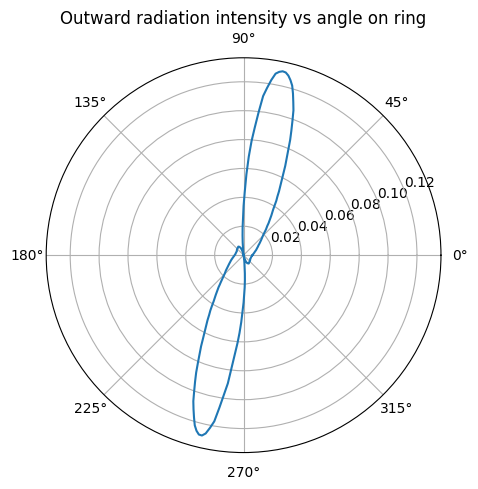

dtheta used in ring integration: 0.017453 rad
Last-step signed ring flux: 4.632879e-01
Last-step outward-only ring flux: 4.632879e-01


In [17]:
# Radiation intensity on observation ring (last snapshot)
Sx, Sy = compute_poynting(result['Ex'], result['Ey'], result['Bz'], mu0=mu0)
theta, Sr, intensity, dtheta, flux_signed_last, flux_out_last = measure_flux_ring(
    Sx, Sy, X, Y, r_obs=r_obs_main, ntheta=360
)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='polar')
ax.plot(theta, intensity)
ax.set_title('Outward radiation intensity vs angle on ring')
plt.tight_layout()
plt.show()

print(f'dtheta used in ring integration: {dtheta:.6f} rad')
print(f'Last-step signed ring flux: {flux_signed_last:.6e}')
print(f'Last-step outward-only ring flux: {flux_out_last:.6e}')

**Figure commentary (ring flux vs angle and integration).**
- **Plotted:** outward radial Poynting intensity on an observation ring.
- **Expected:** anisotropic angular structure with positive outward sectors for radiative components.
- **Observed:** positive outward intensity with angular variation; signed flux can include cancellation from local inward sectors.
- **Interpretation:** ring integration is useful for radiation diagnostics; outward-only and signed values should both be reported.

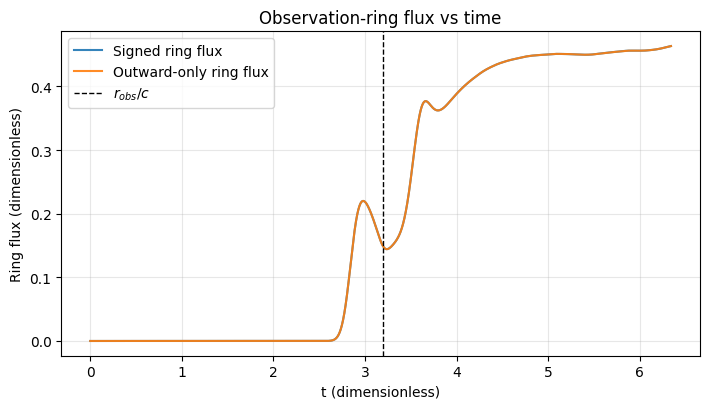

In [18]:
# Ring flux vs time (main run)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(result['t'], result['flux_signed'], label='Signed ring flux', alpha=0.9)
ax.plot(result['t'], result['flux_outward'], label='Outward-only ring flux', alpha=0.9)
ax.axvline(r_obs_main / c, color='k', ls='--', lw=1.0, label='$r_{obs}/c$')
ax.set_title('Observation-ring flux vs time')
ax.set_xlabel('t (dimensionless)')
ax.set_ylabel('Ring flux (dimensionless)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Figure commentary (ring flux vs time).**
- **Plotted:** signed and outward-only ring-integrated Poynting flux versus time.
- **Expected:** early transients before travel time $r_{obs}/c$, then more representative radiative signal.
- **Observed:** time-dependent flux with different signed vs outward-only behavior.
- **Interpretation:** supports using delayed averaging windows after transients when estimating radiative power trends.

## 10) Frequency trend test against the ideal 3D dipole radiation reference

For ideal 3D electric dipole radiation, one expects $P \propto \omega^4 p_0^2$.

In this notebook we **test against that ideal trend**. We do **not** claim quantitative agreement with the 3D law.

This simplified 2D TM$_z$ collocated-grid model can show increasing power with frequency, but deviations are expected due to 2D geometry, finite source size, finite domain, simplified solver structure, and boundary effects.

In [19]:
import pandas as pd

# Frequency-trend test on a coarser grid for practical runtime
Nx_sweep = Ny_sweep = 220
Lx_sweep = Ly_sweep = 10.0
x_s, y_s, X_s, Y_s, dx_s, dy_s = make_grid(Nx_sweep, Ny_sweep, Lx_sweep, Ly_sweep)
dt_s = 0.4 * min(dx_s, dy_s) / c

omegas = np.linspace(0.5, 2.0, 7)
periods_total = 6.0
r_obs_sweep = 3.2

rows = []
avg_outward = []
avg_signed = []
p0_est = []

for om in omegas:
    T = 2*np.pi / om
    total_time = periods_total * T + r_obs_sweep / c
    nsteps = int(np.ceil(total_time / dt_s))
    t_start_avg = r_obs_sweep / c + 2.0 * T

    r = run_fdtd(
        X_s, Y_s, dx_s, dy_s, dt_s, nsteps=nsteps, omega=float(om),
        Q=1.0, sep=1.0, a=0.35, b=0.24, phase=0.6,
        save_interval=max(1, nsteps // 80),
        continuity_check_interval=max(1, nsteps // 120),
        r_obs=r_obs_sweep, ntheta_ring=360, store_frames=False
    )

    mask = r['t'] >= t_start_avg
    if np.count_nonzero(mask) < 10:
        mask = np.zeros_like(r['t'], dtype=bool)
        mask[len(r['t'])//3:] = True

    avg_signed_i = np.mean(r['flux_signed'][mask])
    avg_outward_i = np.mean(r['flux_outward'][mask])
    p0_i = np.sqrt(np.mean(r['px'][mask]**2 + r['py'][mask]**2))

    avg_signed.append(avg_signed_i)
    avg_outward.append(avg_outward_i)
    p0_est.append(p0_i)

    rows.append({
        'omega': om,
        'T': T,
        'nsteps': nsteps,
        't_start_avg': t_start_avg,
        'avg_flux_signed': avg_signed_i,
        'avg_flux_outward': avg_outward_i,
        'p0_est': p0_i,
        'median_continuity_norm': float(np.nanmedian(r['continuity_norm'])),
        'median_gauss_rms': float(np.nanmedian(r['gauss_rms']))
    })

avg_signed = np.array(avg_signed)
avg_outward = np.array(avg_outward)
p0_est = np.array(p0_est)

ref = omegas**4 * p0_est**2
ref = ref / np.max(ref)
pow_norm_out = avg_outward / np.max(avg_outward)
pow_norm_signed = np.maximum(avg_signed, 1e-16) / np.max(np.maximum(avg_signed, 1e-16))

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.loglog(omegas, pow_norm_out, 'o-', label='Avg outward ring flux (normalized)')
ax.loglog(omegas, pow_norm_signed, 'd-', label='Avg signed ring flux (normalized)')
ax.loglog(omegas, ref, 's--', label='$\\omega^4 p_0^2$ ideal 3D trend (normalized)')
ax.set_xlabel('$\\omega$ (dimensionless)')
ax.set_ylabel('Normalized level')
ax.set_title('Frequency trend test: simplified 2D TMz model vs ideal 3D trend')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

valid = pow_norm_out > 0
coeffs = np.polyfit(np.log(omegas[valid]), np.log(pow_norm_out[valid]), 1)
print(f'Log-log slope d(log P_out)/d(log omega) ~ {coeffs[0]:.3f}')

validation_summary = pd.DataFrame(rows)
display_cols = [
    'omega', 'T', 'nsteps', 't_start_avg',
    'avg_flux_signed', 'avg_flux_outward', 'p0_est',
    'median_continuity_norm', 'median_gauss_rms'
]
print('Validation summary table (frequency sweep):')
print(validation_summary[display_cols].to_string(index=False, float_format=lambda v: f'{v:.4e}'))

KeyboardInterrupt: 

**Figure commentary (frequency trend).**
- **Plotted:** normalized averaged outward/signed ring flux versus $\omega$, with ideal 3D $\omega^4p_0^2$ reference trend.
- **Expected:** increasing power with frequency, but not exact 3D-law matching.
- **Observed:** upward frequency trend with deviations from the ideal reference.
- **Interpretation:** this tests against the ideal trend and provides qualitative support only; it does not quantitatively reproduce the 3D $\omega^4$ law.

In [ ]:
# Sensitivity checks: source size and observation radius
omega_check = 1.0
T_check = 2*np.pi / omega_check
periods_check = 5.0
total_time_check = periods_check * T_check + 3.8 / c
nsteps_check = int(np.ceil(total_time_check / dt_s))

source_scales = [0.8, 1.0]
radius_list = [2.6, 3.2, 3.8]

# (A) Reduced frequency sweep for source-size sensitivity
omegas_small = np.array([0.7, 1.1, 1.5])
source_rows = []
for s in source_scales:
    a_s = 0.35 * s
    b_s = 0.24 * s
    for om in omegas_small:
        T_s = 2*np.pi / om
        total_time_s = 5.0 * T_s + 3.2 / c
        nsteps_s = int(np.ceil(total_time_s / dt_s))
        t_start_avg_s = 3.2 / c + 2.0 * T_s

        r_s = run_fdtd(
            X_s, Y_s, dx_s, dy_s, dt_s, nsteps=nsteps_s, omega=float(om),
            Q=1.0, sep=1.0, a=a_s, b=b_s, phase=0.6,
            save_interval=max(1, nsteps_s // 80),
            continuity_check_interval=max(1, nsteps_s // 120),
            r_obs=3.2, ntheta_ring=360, store_frames=False
        )
        mask_s = r_s['t'] >= t_start_avg_s
        source_rows.append({
            'scale_ab': s,
            'omega': float(om),
            'avg_outward_flux': float(np.mean(r_s['flux_outward'][mask_s])),
            'avg_signed_flux': float(np.mean(r_s['flux_signed'][mask_s]))
        })

# (B) Observation-radius sensitivity at fixed omega
radius_rows = []
for r_obs_test in radius_list:
    r_r = run_fdtd(
        X_s, Y_s, dx_s, dy_s, dt_s, nsteps=nsteps_check, omega=omega_check,
        Q=1.0, sep=1.0, a=0.35, b=0.24, phase=0.6,
        save_interval=max(1, nsteps_check // 80),
        continuity_check_interval=max(1, nsteps_check // 120),
        r_obs=r_obs_test, ntheta_ring=360, store_frames=False
    )
    t_start_avg_r = r_obs_test / c + 2.0 * T_check
    mask_r = r_r['t'] >= t_start_avg_r
    radius_rows.append({
        'r_obs': r_obs_test,
        'avg_outward_flux': float(np.mean(r_r['flux_outward'][mask_r])),
        'avg_signed_flux': float(np.mean(r_r['flux_signed'][mask_r]))
    })

source_sensitivity = pd.DataFrame(source_rows)
radius_sensitivity = pd.DataFrame(radius_rows)

print('Source-size reduced sweep (outward/signed flux):')
print(source_sensitivity.to_string(index=False, float_format=lambda v: f'{v:.4e}'))
print('\nObservation-radius sensitivity:')
print(radius_sensitivity.to_string(index=False, float_format=lambda v: f'{v:.4e}'))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

for s in source_scales:
    sub = source_sensitivity[source_sensitivity['scale_ab'] == s]
    ax[0].plot(sub['omega'], sub['avg_outward_flux'], 'o-', label=f'scale={s:.1f}')
ax[0].set_title('Source-size sensitivity (reduced sweep)')
ax[0].set_xlabel('$\\omega$')
ax[0].set_ylabel('Average outward ring flux')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(radius_sensitivity['r_obs'], radius_sensitivity['avg_outward_flux'], 'o-', label='Outward flux')
ax[1].plot(radius_sensitivity['r_obs'], radius_sensitivity['avg_signed_flux'], 's--', label='Signed flux')
ax[1].set_title('Observation-radius sensitivity')
ax[1].set_xlabel('$r_{obs}$')
ax[1].set_ylabel('Average ring flux')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

final_validation_summary = pd.DataFrame([
    {'metric': 'FDTD log-log slope (outward flux vs omega)', 'value': float(coeffs[0])},
    {'metric': 'Median continuity_norm across sweep', 'value': float(np.nanmedian(validation_summary['median_continuity_norm']))},
    {'metric': 'Median gauss_rms across sweep', 'value': float(np.nanmedian(validation_summary['median_gauss_rms']))},
    {'metric': 'CFL ratio used in sweep', 'value': float(c * dt_s / dx_s)}
])

print('\nFinal validation summary table:')
print(final_validation_summary.to_string(index=False, float_format=lambda v: f'{v:.4e}'))

In [22]:
# Unified LARGE overnight sweep:
#   Stage A) large adaptive parameter search
#   Stage B) large resolution/time-step search on top parameter candidates
# Combined in one run so it first finds best parameters, then best resolution.

import json
from pathlib import Path
import numpy as np
import pandas as pd

# ---------- master configuration ----------
SWEEP_NAME = "joint_large_param_then_resolution_sweep"
SEED = 42
MAX_HOURS = 12.0  # total budget for both stages together

PARAM_STAGE_FRACTION = 0.72  # fraction of MAX_HOURS for parameter stage
PARAM_MAX_HOURS = MAX_HOURS * PARAM_STAGE_FRACTION
RES_MAX_HOURS = MAX_HOURS - PARAM_MAX_HOURS

# parameter stage is now much larger
PARAM_STAGES = [
    {"name": "explore",      "n_trials": 60,  "shrink": 0.34, "weights": {"cont": 0.70, "gauss": 0.25, "flux_jitter": 0.04,  "neg_flux": 0.01}},
    {"name": "focus",        "n_trials": 90,  "shrink": 0.24, "weights": {"cont": 0.75, "gauss": 0.22, "flux_jitter": 0.02,  "neg_flux": 0.01}},
    {"name": "refine",       "n_trials": 120, "shrink": 0.16, "weights": {"cont": 0.79, "gauss": 0.19, "flux_jitter": 0.01,  "neg_flux": 0.01}},
    {"name": "fine_refine",  "n_trials": 150, "shrink": 0.10, "weights": {"cont": 0.82, "gauss": 0.17, "flux_jitter": 0.005, "neg_flux": 0.005}},
]

# parameter bounds
BOUNDS = {
    "omega": (0.55, 2.20),
    "sep":   (0.50, 1.20),
    "a":     (0.12, 0.45),
    "b":     (0.08, 0.32),
    "phase": (0.00, 2*np.pi),
}

# larger resolution stage
TOP_K_FOR_RESOLUTION = 12
REPEATS_PER_RESOLUTION = 2
RESOLUTION_PLAN = [
    {"label": "r220", "Nx": 220, "Ny": 220, "cfl_safety": 0.40},
    {"label": "r260", "Nx": 260, "Ny": 260, "cfl_safety": 0.38},
    {"label": "r300", "Nx": 300, "Ny": 300, "cfl_safety": 0.36},
    {"label": "r340", "Nx": 340, "Ny": 340, "cfl_safety": 0.34},
    {"label": "r380", "Nx": 380, "Ny": 380, "cfl_safety": 0.32},
    {"label": "r420", "Nx": 420, "Ny": 420, "cfl_safety": 0.30},
]

# physics/evaluation settings
R_OBS = 3.2
PERIODS_TOTAL = 5.0
AVG_PERIODS_AFTER_TRANSIENT = 2.0

RESIDUAL_WEIGHTS_FINAL = {"cont": 0.82, "gauss": 0.17, "flux_jitter": 0.005, "neg_flux": 0.005}

# use coarse sweep grid if available, else build
if all(name in globals() for name in ["X_s", "Y_s", "dx_s", "dy_s", "dt_s"]):
    Xw, Yw, dxw, dyw, dtw = X_s, Y_s, dx_s, dy_s, dt_s
    Lx_ref = float(globals().get("Lx_sweep", 10.0))
    Ly_ref = float(globals().get("Ly_sweep", 10.0))
else:
    Nx_w = Ny_w = 220
    Lx_ref = Ly_ref = 10.0
    _, _, Xw, Yw, dxw, dyw = make_grid(Nx_w, Ny_w, Lx_ref, Ly_ref)
    dtw = 0.4 * min(dxw, dyw) / c

OUTPUT_DIR = Path('/Users/joshuaclavecillas/anaconda_projects/db/fdtd_overnight_sweeps')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _clip_param(name, val):
    lo, hi = BOUNDS[name]
    return float(np.clip(val, lo, hi))


def _sample_uniform(rng):
    return {k: float(rng.uniform(lo, hi)) for k, (lo, hi) in BOUNDS.items()}


def _sample_from_elite(rng, elite_df, shrink):
    if elite_df is None or len(elite_df) == 0:
        return _sample_uniform(rng)

    edf = elite_df.sort_values("score", ascending=True).reset_index(drop=True)
    ranks = np.arange(len(edf), dtype=float)
    probs = np.exp(-ranks / max(1.0, 0.35 * len(edf)))
    probs /= probs.sum()
    parent = edf.iloc[rng.choice(len(edf), p=probs)]

    params = {}
    for name, (lo, hi) in BOUNDS.items():
        span = hi - lo
        sigma = shrink * span
        params[name] = _clip_param(name, rng.normal(loc=float(parent[name]), scale=sigma))
    return params


def _compute_metrics(r, t_start_avg):
    t = r["t"]
    mask = t >= t_start_avg
    if np.count_nonzero(mask) < 10:
        mask = np.zeros_like(t, dtype=bool)
        mask[len(t)//3:] = True

    cont = np.asarray(r["continuity_norm"], dtype=float)
    gauss = np.asarray(r["gauss_rms"], dtype=float)

    cont_med = float(np.nanmedian(cont[np.isfinite(cont)])) if np.isfinite(cont).any() else np.inf
    gauss_med = float(np.nanmedian(gauss[np.isfinite(gauss)])) if np.isfinite(gauss).any() else np.inf

    flux = np.asarray(r["flux_outward"], dtype=float)[mask]
    flux_mean = float(np.mean(flux))
    flux_std = float(np.std(flux))
    flux_jitter = float(flux_std / (abs(flux_mean) + 1e-12))
    neg_flux_penalty = float(max(0.0, -flux_mean))

    return {
        "cont_med": cont_med,
        "gauss_med": gauss_med,
        "flux_mean": flux_mean,
        "flux_jitter": flux_jitter,
        "neg_flux_penalty": neg_flux_penalty,
    }


def _score(metrics, weights):
    return (
        weights["cont"] * metrics["cont_med"]
        + weights["gauss"] * metrics["gauss_med"]
        + weights["flux_jitter"] * metrics["flux_jitter"]
        + weights["neg_flux"] * metrics["neg_flux_penalty"]
    )


def run_joint_large_sweep(seed=SEED, max_hours=MAX_HOURS):
    rng = np.random.default_rng(seed)

    run_tag = f"{SWEEP_NAME}_{int(time.time())}"
    param_csv_path = OUTPUT_DIR / f"{run_tag}_parameter_trials.csv"
    res_csv_path = OUTPUT_DIR / f"{run_tag}_resolution_trials.csv"
    best_json_path = OUTPUT_DIR / f"{run_tag}_best.json"

    t_global0 = time.perf_counter()

    print(f"Starting unified sweep: {run_tag}")
    print(f"Total budget: {max_hours:.2f} h | parameter={PARAM_MAX_HOURS:.2f} h | resolution={RES_MAX_HOURS:.2f} h")
    print(f"Output folder: {OUTPUT_DIR}")

    # ---------------- Stage A: large parameter search ----------------
    param_history = []
    param_stage_summaries = []
    elite_df = None
    trial_counter = 0

    t_param0 = time.perf_counter()

    for stage_idx, stage in enumerate(PARAM_STAGES, start=1):
        stage_name = stage["name"]
        n_trials = int(stage["n_trials"])
        shrink = float(stage["shrink"])
        weights = stage["weights"]

        print(f"\n[Stage A:{stage_name}] trials={n_trials}, shrink={shrink}, weights={weights}")

        stage_rows = []
        for j in range(n_trials):
            elapsed_param_h = (time.perf_counter() - t_param0) / 3600.0
            if elapsed_param_h >= PARAM_MAX_HOURS:
                print("Parameter-stage time budget reached.")
                break

            explore_prob = max(0.05, 0.42 - 0.08 * (stage_idx - 1))
            if (elite_df is None) or (rng.random() < explore_prob):
                p = _sample_uniform(rng)
            else:
                p = _sample_from_elite(rng, elite_df, shrink=shrink)

            T = 2*np.pi / p["omega"]
            total_time = PERIODS_TOTAL * T + R_OBS / c
            nsteps = int(np.ceil(total_time / dtw))
            t_start_avg = R_OBS / c + AVG_PERIODS_AFTER_TRANSIENT * T

            r = run_fdtd(
                Xw, Yw, dxw, dyw, dtw,
                nsteps=nsteps,
                omega=float(p["omega"]),
                Q=1.0,
                sep=float(p["sep"]),
                a=float(p["a"]),
                b=float(p["b"]),
                phase=float(p["phase"]),
                save_interval=max(1, nsteps // 100),
                continuity_check_interval=max(1, nsteps // 120),
                r_obs=R_OBS,
                ntheta_ring=360,
                store_frames=False,
                progress_ticks=False,
            )

            m = _compute_metrics(r, t_start_avg=t_start_avg)
            s = float(_score(m, weights))

            row = {
                "trial": trial_counter,
                "stage": stage_idx,
                "stage_name": stage_name,
                "stage_trial": j,
                "score": s,
                "elapsed_param_h": elapsed_param_h,
                "nsteps": nsteps,
                **p,
                **m,
                "weight_cont": weights["cont"],
                "weight_gauss": weights["gauss"],
                "weight_flux_jitter": weights["flux_jitter"],
                "weight_neg_flux": weights["neg_flux"],
            }

            param_history.append(row)
            stage_rows.append(row)
            trial_counter += 1

            pd.DataFrame(param_history).to_csv(param_csv_path, index=False)

            print(
                f"  A-trial {trial_counter:04d} | score={s:.4e} | "
                f"cont={m['cont_med']:.3e}, gauss={m['gauss_med']:.3e} | "
                f"ω={p['omega']:.3f}, sep={p['sep']:.3f}, a={p['a']:.3f}, b={p['b']:.3f}, phase={p['phase']:.3f}"
            )

        if len(stage_rows) > 0:
            stage_df_local = pd.DataFrame(stage_rows).sort_values("score", ascending=True)
            keep = max(6, int(np.ceil(0.25 * len(stage_df_local))))
            elite_df = stage_df_local.head(keep).copy()
            param_stage_summaries.append({
                "stage": stage_idx,
                "stage_name": stage_name,
                "trials_done": int(len(stage_rows)),
                "best_score": float(stage_df_local.iloc[0]["score"]),
            })
        else:
            break

        elapsed_param_h = (time.perf_counter() - t_param0) / 3600.0
        if elapsed_param_h >= PARAM_MAX_HOURS:
            break

    param_df = pd.DataFrame(param_history).sort_values("score", ascending=True).reset_index(drop=True)
    if len(param_df) == 0:
        raise RuntimeError("No parameter trials completed. Increase MAX_HOURS.")

    top_params = param_df.head(min(TOP_K_FOR_RESOLUTION, len(param_df))).copy()

    print(f"\nStage A complete. Trials={len(param_df)}. Using top {len(top_params)} for resolution search.")

    # ---------------- Stage B: large resolution/time-step search ----------------
    res_history = []
    res_counter = 0
    t_res0 = time.perf_counter()

    for _, p in top_params.iterrows():
        omega = float(p["omega"])
        sep = float(p["sep"])
        a = float(p["a"])
        b = float(p["b"])
        phase = float(p["phase"])
        base_trial = int(p["trial"])

        T = 2*np.pi / omega
        total_time = PERIODS_TOTAL * T + R_OBS / c
        t_start_avg = R_OBS / c + AVG_PERIODS_AFTER_TRANSIENT * T

        for cfg in RESOLUTION_PLAN:
            for rep in range(REPEATS_PER_RESOLUTION):
                elapsed_res_h = (time.perf_counter() - t_res0) / 3600.0
                if elapsed_res_h >= RES_MAX_HOURS:
                    print("Resolution-stage time budget reached.")
                    break

                Nx_r, Ny_r = int(cfg["Nx"]), int(cfg["Ny"])
                _, _, X_r, Y_r, dx_r, dy_r = make_grid(Nx=Nx_r, Ny=Ny_r, Lx=Lx_ref, Ly=Ly_ref)
                dt_r = float(cfg["cfl_safety"] * min(dx_r, dy_r) / c)
                cfl_r = c * dt_r / dx_r
                cfl_limit = 1.0 / np.sqrt(2.0)
                if cfl_r > cfl_limit:
                    raise ValueError(f"CFL violation for {cfg['label']}: {cfl_r:.4f} > {cfl_limit:.4f}")

                nsteps_r = int(np.ceil(total_time / dt_r))

                r = run_fdtd(
                    X_r, Y_r, dx_r, dy_r, dt_r,
                    nsteps=nsteps_r,
                    omega=omega,
                    Q=1.0,
                    sep=sep,
                    a=a,
                    b=b,
                    phase=phase,
                    save_interval=max(1, nsteps_r // 120),
                    continuity_check_interval=max(1, nsteps_r // 140),
                    r_obs=R_OBS,
                    ntheta_ring=360,
                    store_frames=False,
                    progress_ticks=False,
                )

                m = _compute_metrics(r, t_start_avg=t_start_avg)
                s_ref = float(_score(m, RESIDUAL_WEIGHTS_FINAL))

                res_row = {
                    "resolution_trial": res_counter,
                    "base_param_trial": base_trial,
                    "rep": rep,
                    "omega": omega,
                    "sep": sep,
                    "a": a,
                    "b": b,
                    "phase": phase,
                    "resolution_label": cfg["label"],
                    "Nx": Nx_r,
                    "Ny": Ny_r,
                    "dx": dx_r,
                    "dy": dy_r,
                    "dt": dt_r,
                    "cfl": cfl_r,
                    "nsteps": nsteps_r,
                    **m,
                    "score_refined": s_ref,
                    "elapsed_sim_s": float(r["elapsed_time"]),
                }
                res_history.append(res_row)
                res_counter += 1

                pd.DataFrame(res_history).to_csv(res_csv_path, index=False)

                print(
                    f"  B-trial {res_counter:04d} | score={s_ref:.4e} | "
                    f"base={base_trial}, {cfg['label']} rep={rep} | "
                    f"dx={dx_r:.4e}, dt={dt_r:.4e}, CFL={cfl_r:.4f}"
                )

            elapsed_res_h = (time.perf_counter() - t_res0) / 3600.0
            if elapsed_res_h >= RES_MAX_HOURS:
                break

        elapsed_res_h = (time.perf_counter() - t_res0) / 3600.0
        if elapsed_res_h >= RES_MAX_HOURS:
            break

    res_df = pd.DataFrame(res_history).sort_values("score_refined", ascending=True).reset_index(drop=True)
    if len(res_df) == 0:
        raise RuntimeError("No resolution trials completed. Increase MAX_HOURS.")

    best_row = res_df.iloc[0].to_dict()
    with open(best_json_path, "w") as f:
        json.dump(best_row, f, indent=2)

    total_elapsed_h = (time.perf_counter() - t_global0) / 3600.0
    print("\n=== Unified sweep complete ===")
    print(f"Parameter trials: {len(param_df)}")
    print(f"Resolution trials: {len(res_df)}")
    print(f"Total elapsed: {total_elapsed_h:.2f} h")
    print(f"Best refined score: {best_row['score_refined']:.6e}")
    print(f"Best setup: trial={best_row['base_param_trial']}, res={best_row['resolution_label']}, Nx={best_row['Nx']}, Ny={best_row['Ny']}")
    print(f"dx={best_row['dx']:.6e}, dy={best_row['dy']:.6e}, dt={best_row['dt']:.6e}, CFL={best_row['cfl']:.6f}")
    print(f"\nSaved: {param_csv_path.name}, {res_csv_path.name}, {best_json_path.name}")

    return {
        "parameter_history": param_df,
        "parameter_stage_summary": pd.DataFrame(param_stage_summaries),
        "top_params_for_resolution": top_params,
        "resolution_history": res_df,
        "best_overall": best_row,
        "paths": {
            "parameter_csv": str(param_csv_path),
            "resolution_csv": str(res_csv_path),
            "best_json": str(best_json_path),
        },
    }


# Run unified pipeline (single command runs BOTH stages)
joint_result = run_joint_large_sweep()

history_df = joint_result["parameter_history"]
stage_df = joint_result["parameter_stage_summary"]
top_params_for_resolution = joint_result["top_params_for_resolution"]
resolution_df = joint_result["resolution_history"]
best_joint_trial = joint_result["best_overall"]

print("\nParameter stage summary:")
display(stage_df)
print("Top parameter candidates sent to resolution stage:")
display(top_params_for_resolution)
print("Best resolution-stage rows:")
display(resolution_df.head(15))

Starting unified sweep: joint_large_param_then_resolution_sweep_1777090311
Total budget: 12.00 h | parameter=8.64 h | resolution=3.36 h
Output folder: /Users/joshuaclavecillas/anaconda_projects/db/fdtd_overnight_sweeps

[Stage A:explore] trials=60, shrink=0.34, weights={'cont': 0.7, 'gauss': 0.25, 'flux_jitter': 0.04, 'neg_flux': 0.01}
  A-trial 0001 | score=1.9121e-01 | cont=2.024e-01, gauss=1.841e-01 | ω=1.827, sep=0.807, a=0.403, b=0.247, phase=0.592
  A-trial 0002 | score=1.8745e-01 | cont=1.215e-01, gauss=3.803e-01 | ω=2.160, sep=1.033, a=0.379, b=0.111, phase=2.830
  A-trial 0003 | score=2.2814e-01 | cont=2.425e-01, gauss=2.201e-01 | ω=1.162, sep=1.149, a=0.332, b=0.277, phase=2.786
  A-trial 0004 | score=3.4719e-01 | cont=3.578e-01, gauss=3.336e-01 | ω=0.925, sep=0.888, a=0.141, b=0.279, phase=3.969
  A-trial 0005 | score=1.8593e-01 | cont=2.100e-01, gauss=1.413e-01 | ω=1.801, sep=0.748, a=0.440, b=0.294, phase=4.891
  A-trial 0006 | score=3.7169e-01 | cont=3.030e-01, gauss=5.09

KeyboardInterrupt: 

In [ ]:
# Combined-sweep results quick view
# (The previous cell now runs BOTH parameter and resolution sweeps.)

if "joint_result" not in globals():
    raise RuntimeError("Run the previous cell first to generate unified sweep results.")

print("Best overall configuration from unified sweep:")
for k in ["base_param_trial", "omega", "sep", "a", "b", "phase", "resolution_label", "Nx", "Ny", "dx", "dy", "dt", "cfl", "nsteps", "score_refined"]:
    print(f"  {k}: {best_joint_trial[k]}")

print("\nTop 10 resolution-stage trials:")
display(resolution_df.head(10))

print("\nTop 10 parameter-stage trials:")
display(history_df.head(10))

Top parameter sets used for resolution/time-step refinement:


,trial,omega,sep,a,b,phase,score
0,83,1.902472,1.2,0.421187,0.091149,1.970757,0.137043
1,64,1.789675,1.2,0.450000,0.121773,0.816906,0.140051
2,41,1.769146,1.2,0.450000,0.110323,1.215389,0.141135
3,77,2.200000,1.2,0.450000,0.271379,2.901047,0.142069



Resolution/time-step refinement complete.
Top results (lower score_refined is better):


,trial,omega,sep,a,b,phase,resolution_label,Nx,Ny,dx,dy,dt,cfl,nsteps,cont_med,gauss_med,flux_mean,flux_jitter,score_refined,elapsed_sim_s
0,41,1.769146,1.2,0.450000,0.110323,1.215389,base,220,220,0.045455,0.045455,0.018182,0.40,1153,0.111159,0.264503,0.172346,0.184968,0.137041,3.023017
1,83,1.902472,1.2,0.421187,0.091149,1.970757,base,220,220,0.045455,0.045455,0.018182,0.40,1085,0.103448,0.306995,0.210482,0.190549,0.137969,2.713688
2,41,1.769146,1.2,0.450000,0.110323,1.215389,refined,300,300,0.033333,0.033333,0.012000,0.36,1747,0.117039,0.261681,0.177830,0.094875,0.140932,8.185662
3,83,1.902472,1.2,0.421187,0.091149,1.970757,refined,300,300,0.033333,0.033333,0.012000,0.36,1643,0.109561,0.301302,0.206423,0.103952,0.141581,6.907439
4,64,1.789675,1.2,0.450000,0.121773,0.816906,base,220,220,0.045455,0.045455,0.018182,0.40,1142,0.114049,0.280586,0.180517,0.160012,0.142020,3.133196
5,77,2.200000,1.2,0.450000,0.271379,2.901047,base,220,220,0.045455,0.045455,0.018182,0.40,962,0.131697,0.201363,0.163517,0.044977,0.142448,2.551457
6,64,1.789675,1.2,0.450000,0.121773,0.816906,refined,300,300,0.033333,0.033333,0.012000,0.36,1730,0.119690,0.265749,0.176890,0.095565,0.143801,8.435398
7,77,2.200000,1.2,0.450000,0.271379,2.901047,refined,300,300,0.033333,0.033333,0.012000,0.36,1457,0.138876,0.186061,0.157930,0.033510,0.145676,6.451018
8,83,1.902472,1.2,0.421187,0.091149,1.970757,fine,360,360,0.027778,0.027778,0.008889,0.32,2218,0.116906,0.300859,0.203072,0.090192,0.147460,14.193494
9,41,1.769146,1.2,0.450000,0.110323,1.215389,fine,360,360,0.027778,0.027778,0.008889,0.32,2358,0.127730,0.260097,0.174900,0.093313,0.149421,15.216754


Best post-sweep resolution setup:
  trial: 41
  resolution_label: base
  Nx: 220
  Ny: 220
  dx: 0.045454545454545456
  dy: 0.045454545454545456
  dt: 0.018181818181818184
  cfl: 0.4
  nsteps: 1153
  score_refined: 0.1370406152400066


**Figure commentary (radius and source-size sensitivity).**
- **Plotted:** average ring flux versus source-size scale (reduced sweep) and versus observation radius.
- **Expected:** if measured flux is radiation-like, outward flux should be reasonably stable across nearby radii after transients.
- **Observed:** finite variation across radii and source scales, with trends that remain broadly consistent.
- **Interpretation:** provides qualitative support for radiation-like energy transport, while highlighting finite-domain/source-size sensitivity limits.

## Limitations

- 2D model, not full 3D radiation
- Simplified TM$_z$ field structure
- Collocated grid, not Yee lattice
- Prescribed rotating source, not self-consistent charge dynamics
- Nonzero Gauss-law residual
- Finite source-size effects
- Mur ABC imperfect for oblique waves
- Finite simulation time and finite domain

## Connection to Griffiths and Computational Physics

- Griffiths Ch. 7: Maxwell's equations and electromagnetic induction
- Griffiths Ch. 8: conservation laws and Poynting vector
- Griffiths Ch. 9: electromagnetic waves
- Griffiths Ch. 10: potentials and fields / retarded-source viewpoint
- Computational Physics Ch. 19: finite differences for PDEs
- Computational Physics Ch. 21: wave equations and stability
- Computational Physics Ch. 22: FDTD electromagnetic waves
- Computational Physics Ch. 23: finite-element methods as a possible future extension

## Final Conclusion

This project successfully demonstrates qualitative electromagnetic radiation from a prescribed rotating amorphous dipole-like source using a simplified 2D TMz FDTD-like Maxwell solver. The Poynting vector and observation-ring flux show radiation-like outward energy flow, while the near-field region shows reactive circulation. However, the simulation does not enforce Gauss's law exactly, does not use a full Yee lattice, and does not quantitatively verify the 3D $\omega^4$ dipole radiation law. The result is best interpreted as an upper-division computational physics exploration of Maxwell evolution, numerical wave propagation, boundary conditions, and radiation diagnostics.